# **Ablation Study 1: Qubit Scaling and Dimensionality Bottleneck**

**NOTE:** Use T4 GPU Runtime on Google Colab

#### **Objective**
Our baseline Hybrid Quantum CNN (HQCNN) revealed high variance across random seeds (± 4.97%). A primary suspect for this instability is the extreme classical-to-quantum dimensionality bottleneck. In the baseline, we compressed 512 classical features down to a 4-dimensional state vector.

This experiment tests whether widening the "quantum information pathway" improves model convergence and reduces seed variance.

#### **Hypothesis**
Increasing the number of qubits ($N$) from 2 to 6 will provide the quantum circuit with a larger Hilbert space to map features into $\implies$ thereby increasing average validation accuracy and shrinking the standard deviation across seeds.

* **Fixed Parameters:** Entanglement = `ring`, Layers = `1`, Epochs = `10`, Seeds = `[42, 100, 2026]`
* **Independent Variable:** Qubit Count `[2, 4, 6]`

In [1]:
import os
import sys
import torch
from google.colab import drive

# Mount Drive to access our saved weights
drive.mount('/content/drive')

# Clone repo or pull latest changes
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    os.chdir('/content/QML4EO-reproduction')
    !git pull
else:
    print("Cloning repo for the first time..")
    os.chdir('/content')
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    os.chdir('/content/QML4EO-reproduction')

if '/content/QML4EO-reproduction' not in sys.path:
    sys.path.append('/content/QML4EO-reproduction')

!pip install -r requirements.txt -q

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nHardware utilized: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Cloning repo for the first time..
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 159 (delta 63), reused 130 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 13.67 MiB | 38.45 MiB/s, done.
Resolving deltas: 100% (63/63), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

#### **Initialize Data Loaders**
We must use the exact same resolution ($224\times224$) that we used to fine-tune the classical model $\leftarrow$ so the spatial dimensions perfectly match the saved weights.

In [2]:
from src.utils.data_loader import get_eurosat_dataloaders

# Use the optimized loader parameters (num_workers=2, pin_memory=True)
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=64,
    img_size=224,
    num_workers=2,
    pin_memory=True
)

100%|██████████| 94.3M/94.3M [00:00<00:00, 113MB/s]


Dataset loaded successfully! Total: 27000 | Train: 21600 | Val: 5400


#### **The Qubit Ablation Loop**
We evaluate architectures of `2, 4 and 6 qubits`

To ensure mathematical rigor and account for the highly non-convex quantum loss landscape, every architecture is evaluated across 3 distinct random initializations (`SEEDS = [42, 100, 2026]`).

In [3]:
import numpy as np
from src.baselines.cnn import set_seed
from src.models.hqcnn import HybridQCNN, train_decoupled_hqcnn

# Path to the weights we generated in Notebook 2
WEIGHTS_PATH = '/content/drive/MyDrive/QML4EO-reproduction/models/finetuned_resnet18_eurosat.pth'

# Fixed Hyperparameters (Isolating the Qubit variable)
ENTANGLEMENT = "ring"
LAYERS = 1
EPOCHS = 10
SEEDS = [42, 100, 2026]

# Ablation Variable
QUBIT_LIST = [2, 4, 6]

# Dictionary to store all statistical results
ablation_results = {}

print(f"\nStarting Ablation 1: Qubit Scaling")

for qubits in QUBIT_LIST:
    print(f"EXPERIMENT: {qubits} QUBITS")

    all_train_losses = []
    all_val_accs = []

    for seed in SEEDS:
        print(f"\n▶ TRAINING SEED: {seed}")
        print("-" * 30)

        set_seed(seed)

        # Initialize Hybrid Model
        model = HybridQCNN(
            num_classes=len(classes),
            num_qubits=qubits,
            num_layers=LAYERS,
            entanglement_type=ENTANGLEMENT,
            pretrained_weights_path=WEIGHTS_PATH
        )

        # Run the Decoupled Training Loop
        history = train_decoupled_hqcnn(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            device=device
        )

        all_train_losses.append(history['train_loss'])
        all_val_accs.append(history['val_acc'])

    # Calculate statistics for this specific qubit count
    acc_array = np.array(all_val_accs)
    loss_array = np.array(all_train_losses)

    ablation_results[qubits] = {
        'mean_acc': np.mean(acc_array, axis=0),
        'std_acc': np.std(acc_array, axis=0),
        'mean_loss': np.mean(loss_array, axis=0),
        'std_loss': np.std(loss_array, axis=0)
    }

    final_mean = ablation_results[qubits]['mean_acc'][-1]
    final_std = ablation_results[qubits]['std_acc'][-1]
    print(f"\n{qubits}-Qubit Phase Complete → Final Avg Acc: {final_mean:.2f}% ± {final_std:.2f}%")


Starting Ablation 1: Qubit Scaling
EXPERIMENT: 2 QUBITS

▶ TRAINING SEED: 42
------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]
Epoch 1/10 [Train]: 100%|██████████| 338/338 [01:00<00:00,  5.63it/s, loss=2.0350]


Epoch 1 Summary → Train Loss: 2.0791 | Val Accuracy: 33.24%


Epoch 2/10 [Train]: 100%|██████████| 338/338 [00:57<00:00,  5.84it/s, loss=1.8955]


Epoch 2 Summary → Train Loss: 1.8899 | Val Accuracy: 33.41%


...

Epoch 8 Summary → Train Loss: 0.5203 | Val Accuracy: 93.98%


Epoch 9/10 [Train]: 100%|██████████| 338/338 [01:04<00:00,  5.28it/s, loss=0.3505]


Epoch 9 Summary → Train Loss: 0.4244 | Val Accuracy: 94.94%


Epoch 10/10 [Train]: 100%|██████████| 338/338 [01:03<00:00,  5.33it/s, loss=0.2186]


Epoch 10 Summary → Train Loss: 0.3711 | Val Accuracy: 95.69%

6-Qubit Phase Complete → Final Avg Acc: 80.17% ± 20.80%


#### **Visualization & Statistical Analysis**
The graphs below plot the mean performance across all seeds. Shaded regions represent $± Standard Deviation$. 

NOTE: A narrower shaded band indicates a more stable architecture that is less reliant on "lucky" weight initialization.

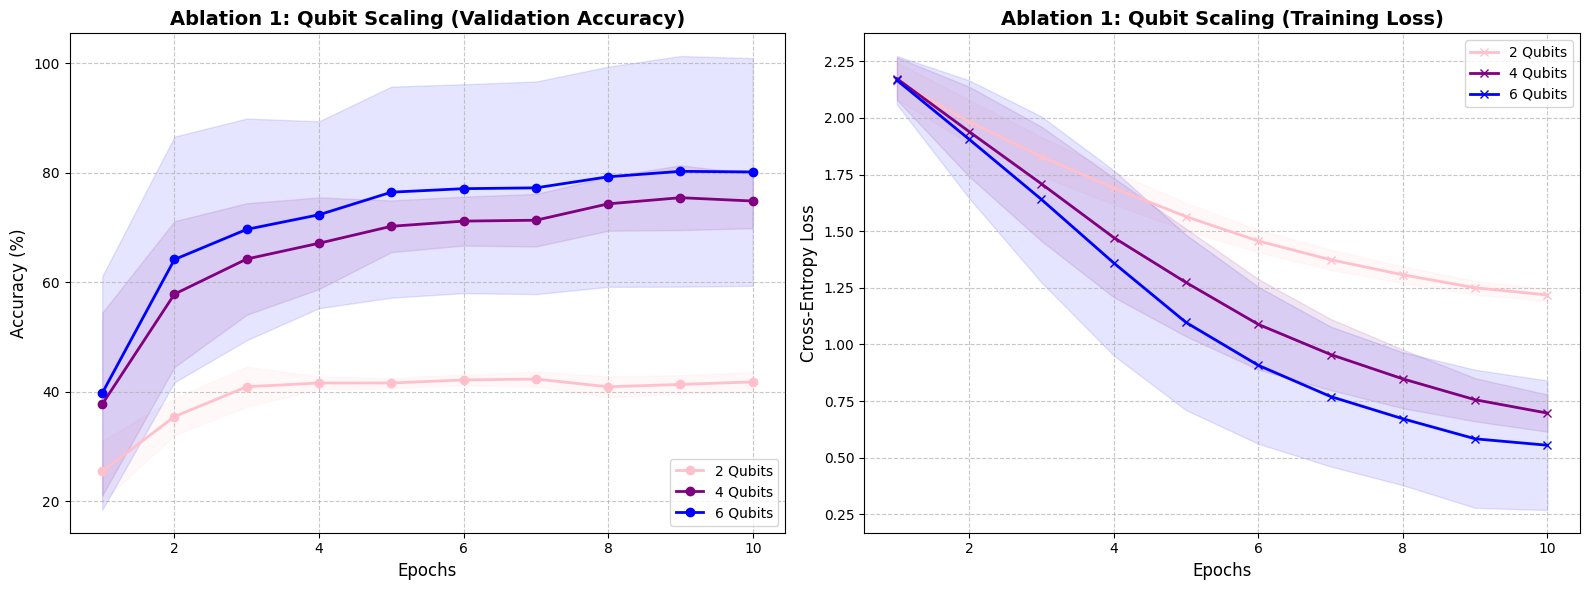

In [5]:
epochs_range = range(1, EPOCHS + 1)
colors = {2: 'pink', 4: 'purple', 6: 'blue'}
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

# Plot 1: Validation Accuracy Comparison
plt.subplot(1, 2, 1)
for qubits in QUBIT_LIST:
    mean_acc = ablation_results[qubits]['mean_acc']
    std_acc = ablation_results[qubits]['std_acc']

    plt.plot(epochs_range, mean_acc, label=f'{qubits} Qubits', color=colors[qubits], marker='o', linewidth=2)
    plt.fill_between(epochs_range, mean_acc - std_acc, mean_acc + std_acc, color=colors[qubits], alpha=0.1)

plt.title('Ablation 1: Qubit Scaling (Validation Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Plot 2: Training Loss Comparison
plt.subplot(1, 2, 2)
for qubits in QUBIT_LIST:
    mean_loss = ablation_results[qubits]['mean_loss']
    std_loss = ablation_results[qubits]['std_loss']

    plt.plot(epochs_range, mean_loss, label=f'{qubits} Qubits', color=colors[qubits], marker='x', linewidth=2)
    plt.fill_between(epochs_range, mean_loss - std_loss, mean_loss + std_loss, color=colors[qubits], alpha=0.1)

plt.title('Ablation 1: Qubit Scaling (Training Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### **Empirical Observations: The Information Bottleneck and Qubit Scaling**

The results of this ablation study perfectly illustrate the **Information Bottleneck** phenomenon in Hybrid Quantum-Classical architectures:

* **2 Qubits (Under-parameterized):** 
    * The model completely failed to converge $\leftarrow$ maxing out around 41.81% ± 1.79% accuracy
    * By brutally compressing 512 high-dimensional classical features down to just 2 quantum variables $\implies$ critical image data (textures, edges) was permanently lost before it could even reach the quantum circuit. 
* **4 Qubits (The Sweet Spot):** 
    * Achieved a strong balance $\rightarrow$ rapidly climbing to 74.86% ± 4.97% average accuracy
    * The bottleneck was wide enough to pass meaningful feature representations into the quantum layer while remaining mathematically stable.
* **6 Qubits (Diminishing Returns & Instability):** 
    * While capable of hitting extremely high peak accuracies (95.69% on Seed 42), scaling to 6 qubits drastically increased the standard deviation to a massive ± 20.80%
    * The exponentially larger Hilbert space made the loss landscape significantly more jagged $\implies$ causes some initializations (like Seed 100) to get trapped in local minima. 

**Conclusion:** 4 Qubits provides the optimal balance between information bandwidth and mathematical stability. We will lock in `QUBITS = 4` for our subsequent ablation studies to ensure reliable convergence.